In [15]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[2, 4])

nb_name = "proportion_analysis.ipynb"

_compare_version(nb_name)

# Proportion Analysis
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

Differential proportion analysis aims to identify clusters showing differential composition between different biological conditions. Scanpro offers a linear regression framework and empirical bayes moderated statistical tests, taking sample-to-sample variation into account. Scanpro also generate pseudo-replicates automatically for unreplicated data.

In this notebook we will use [Scanpro](https://github.com/loosolab/scanpro). For more information, check the [documentation](https://scanpro.readthedocs.io/en/latest/)

<img src="https://raw.githubusercontent.com/loosolab/scanpro/main/docs/source/figures/scanpro_workflow.png" alt="image" width="65%" height="auto">


___

## 2 - Setup

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.utils.decorator as deco
from sctoolbox.plotting.general import plot_table
import matplotlib.pyplot as plt
from pathlib import Path

# We will use Scanpro for proportion analysis
from scanpro import scanpro

settings.settings_from_config("config.yaml", key="proportion_analysis")

with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Created directory: ../figures/proportion_analysis/
Created directory: ../report/proportion_analysis/


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,anndata,0.12.6
2,scanpy,1.11.5
3,scanpro,0.4.0
4,sctoolbox,NA
5,numpy,2.3.5
6,pandas,2.3.3


___

## 3 - Input/output settings

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
# Input/Output
last_notebook_adata = "anndata_marker_post_annot.h5ad"
output = "anndata_scanpro.h5ad"
plot_suffix = "scanpro"

___

## 4 - Load anndata

In [5]:
adata = utils.adata.load_h5ad(last_notebook_adata)

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

[INFO] The adata object was loaded from: ../adatas/anndata_marker_post_annot.h5ad


AnnData object with n_obs × n_vars = 51409 × 25904
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'Spatial expression domain', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'Combined timepoint clustering', '1.5 dpf pred. cell type', '2 dpf pred. cell type', '3 dpf pred. cell type', '5 dpf pred. cell type', '14 dpf pred. cell type', '60 dpf pred. cell type', '150 dpf pred. cell type', 'Combined pred. cell type', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'sample_density', 'timepoint_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,Combined timepoint clustering,1.5 dpf pred. cell type,2 dpf pred. cell type,3 dpf pred. cell type,5 dpf pred. cell type,14 dpf pred. cell type,60 dpf pred. cell type,150 dpf pred. cell type,Combined pred. cell type,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,timepoint_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering,MR_symbol_leiden_1.5,SCSA_symbol_leiden_1.5,MR_score_leiden_1.5,SCSA_score_leiden_1.5,MR_ui_leiden_1.5,SCSA_ui_leiden_1.5
AAACCTGGTTCACCTC-1-1.5dpf,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.967606,0.935372,S,1_1.5dpf,Periosteum,NaN,NaN,NaN,NaN,NaN,NaN,Periosteum,0,2.106292,1.805305,0.363366,0.363366,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Cycling,Cycling,Mesenchyme,Cycling,Mesenchyme,Cycling
AAACCTGTCCCAAGAT-1-1.5dpf,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.260912,-0.043198,G1,2_1.5dpf,Hyaline cartilage,NaN,NaN,NaN,NaN,NaN,NaN,Hyaline cartilage,1,2.356823,3.274661,0.217232,0.217232,3,4,2,2,2,3,7,5,3,2,3,3,2,2,3,3,3,3,2,3,Neuronal,Otic cells,Neuronal,Otic cells,Neuronal,Otic cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAACACCA-3-150dpf,9,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Teeth,NaN,1300.0,7.170888,85.0,4.454347,6.538462,561.0,6.331502,43.153847,0.059896,False,Male,360,5.888878,-0.133821,-0.121936,G1,1_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Stroma,Stroma,19,1.993680,1.404883,0.343041,0.653931,6,7,10,7,11,12,16,18,15,20,23,15,15,16,19,26,18,30,24,19,Stroma,Perivascular,Stroma,Perivascular,Stroma,Perivascular
TTTGTCATCCGAACGC-3-150dpf,6,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Gill cartilage,NaN,3631.0,8.197538,28.0,3.367296,0.771137,1142.0,7.041412,31.451393,0.074581,False,Male,909,6.813445,-0.262674,-0.138711,G1,9_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Gill cartilage,Gill cartilage,21,1.009526,1.000000,0.728333,0.689964,9,10,13,13,15,17,18,19,21,22,24,26,26,28,28,29,29,32,33,28,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage


---

## 5 - General Input
<hr style="border:2px solid black"> </hr>

### 4.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| clustering_col | The name of a column in `adata.obs` with clustering or celltype annotation | Column should be categorical
| sample_col | The name of a column in `adata.obs` with sample information | Set to None if not available |
| condition_col | The name of a column in `adata.obs` with conditions | Column should be categorical |
| specific_conds | Specify conditions to compare | e.g. `["cond1", "cond2",...]` If None, all conditions are compared |
| pairwise | Set to True to do pairwise comparisons between all conditions. Pairwise comparisons give more insight into changes between each pair of conditions, which can be hard to distinguish with normal comparison | True or False
| trans | Transformation method to normalize proportions | `'logit'` or `'arcsin'` |
| covariates | The name of a column in `adata.obs` with covariates to include in analysis | 
| n_sims | Number of bootstrapping simulations for unreplicated data |
| n_reps | Number of pseudo-replicates to generate for each condition | `int` or `'auto'` to specify automatically |
| significance_threshold | P-value Threshold to determine significane |
| specific_clusters | specify clusters you want to plot | e.g. `["c1", "c2",...]`, set to None to plot all |
| n_cols | Number of plots per row |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [6]:
clustering_col = "MR_ui_leiden_1.5"

sample_col = "sample"

condition_col = "timepoint"
specific_conds = None
pairwise = False

trans = 'logit'

covariates = None

### For unreplicated data ###
# If sample_col=None, data is assumed unreplicated.
# Parameters for the bootstrapping if data is unreplicated
n_sims = 100
n_reps = 8

significance_threshold = 0.05

### Plots ###
# Clusters to plot
specific_clusters = None
n_cols = 4

--------------

## 6 - Proportion analysis with Scanpro

In [7]:
# add decorator to scanpro
scanpro = deco.log_anndata(scanpro)

In [8]:
out = scanpro(adata,
              clusters_col=clustering_col,
              samples_col=sample_col,
              conds_col=condition_col,
              conditions=specific_conds,
              covariates=covariates,
              transform=trans,
              n_sims=n_sims,
              n_reps=n_reps,
              pairwise=pairwise)

results = out.sim_results if hasattr(out, 'sim_results') else out.results

# write results table to automated report section
_ = plot_table(out.results, report=f'01_{plot_suffix}_results.png', crop=None, round=6)

results

[INFO] The following conditions don't have replicates:  1.5dpf, 2dpf
[INFO] Running scanpro with original replicates...
[INFO] There are more than 2 conditions. ANOVA will be performed...
[INFO] Done!
[INFO] Running scanpro with simulated replicates...
[INFO] Generating 8 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 45.04 seconds
[INFO] To access results for original replicates, run <out.results>, and <out.sim_results> for simulated results


,mean_props_1.5dpf,mean_props_2dpf,mean_props_3dpf,mean_props_5dpf,mean_props_14dpf,mean_props_60dpf,mean_props_150dpf,adjusted_p_values
clusters,,,,,,,,
Blood,0.046896,0.001923,0.001631,0.000156,0.000208,0.000000,0.000000,4.866569e-08
Bone,0.000000,0.000000,0.002034,0.013203,0.009887,0.023539,0.002269,2.748190e-04
Dermal fibroblast,0.000000,0.000000,0.000000,0.046321,0.058790,0.031962,0.067694,4.996132e-07
Gill cartilage,0.000000,0.000000,0.000000,0.000237,0.035303,0.224020,0.271605,6.291264e-16
Gill progenitor,0.000000,0.000000,0.000000,0.000451,0.000271,0.238648,0.202980,6.291264e-16
Glia,0.000000,0.000000,0.001579,0.012067,0.028277,0.007410,0.016072,1.796731e-04
Hyaline cartilage,0.000103,0.035700,0.259831,0.084741,0.028885,0.052131,0.001314,9.800432e-10
Intermediate,0.000000,0.000091,0.008965,0.077475,0.000909,0.001315,0.000082,1.560865e-09
Mesenchyme,0.728939,0.526461,0.522669,0.018695,0.001045,0.000531,0.000106,4.718448e-16


In [9]:
# adjusted p-value is only in combination with sample information present
sig_col = "adjusted_p_values"

if not out.pairwise:
    significant_change = (out.results[sig_col] < significance_threshold).to_dict()
else:
    significant_change = {ct: {f"{pair[0]} vs {pair[1]}": out.results.loc[ct, f'{sig_col}_{pair[0]}_{pair[1]}'] < significance_threshold for pair in out.condition_pairs} for ct in out.results.index}
significant_change

{'Blood': True,
 'Bone': True,
 'Dermal fibroblast': True,
 'Gill cartilage': True,
 'Gill progenitor': True,
 'Glia': True,
 'Hyaline cartilage': True,
 'Intermediate': True,
 'Mesenchyme': True,
 'Neuronal': True,
 'Otic cells': True,
 'Perichondrium': True,
 'Perivascular': True,
 'Posterior': True,
 'Smooth muscle': True,
 'Stroma': True,
 'Xanthophore': True}

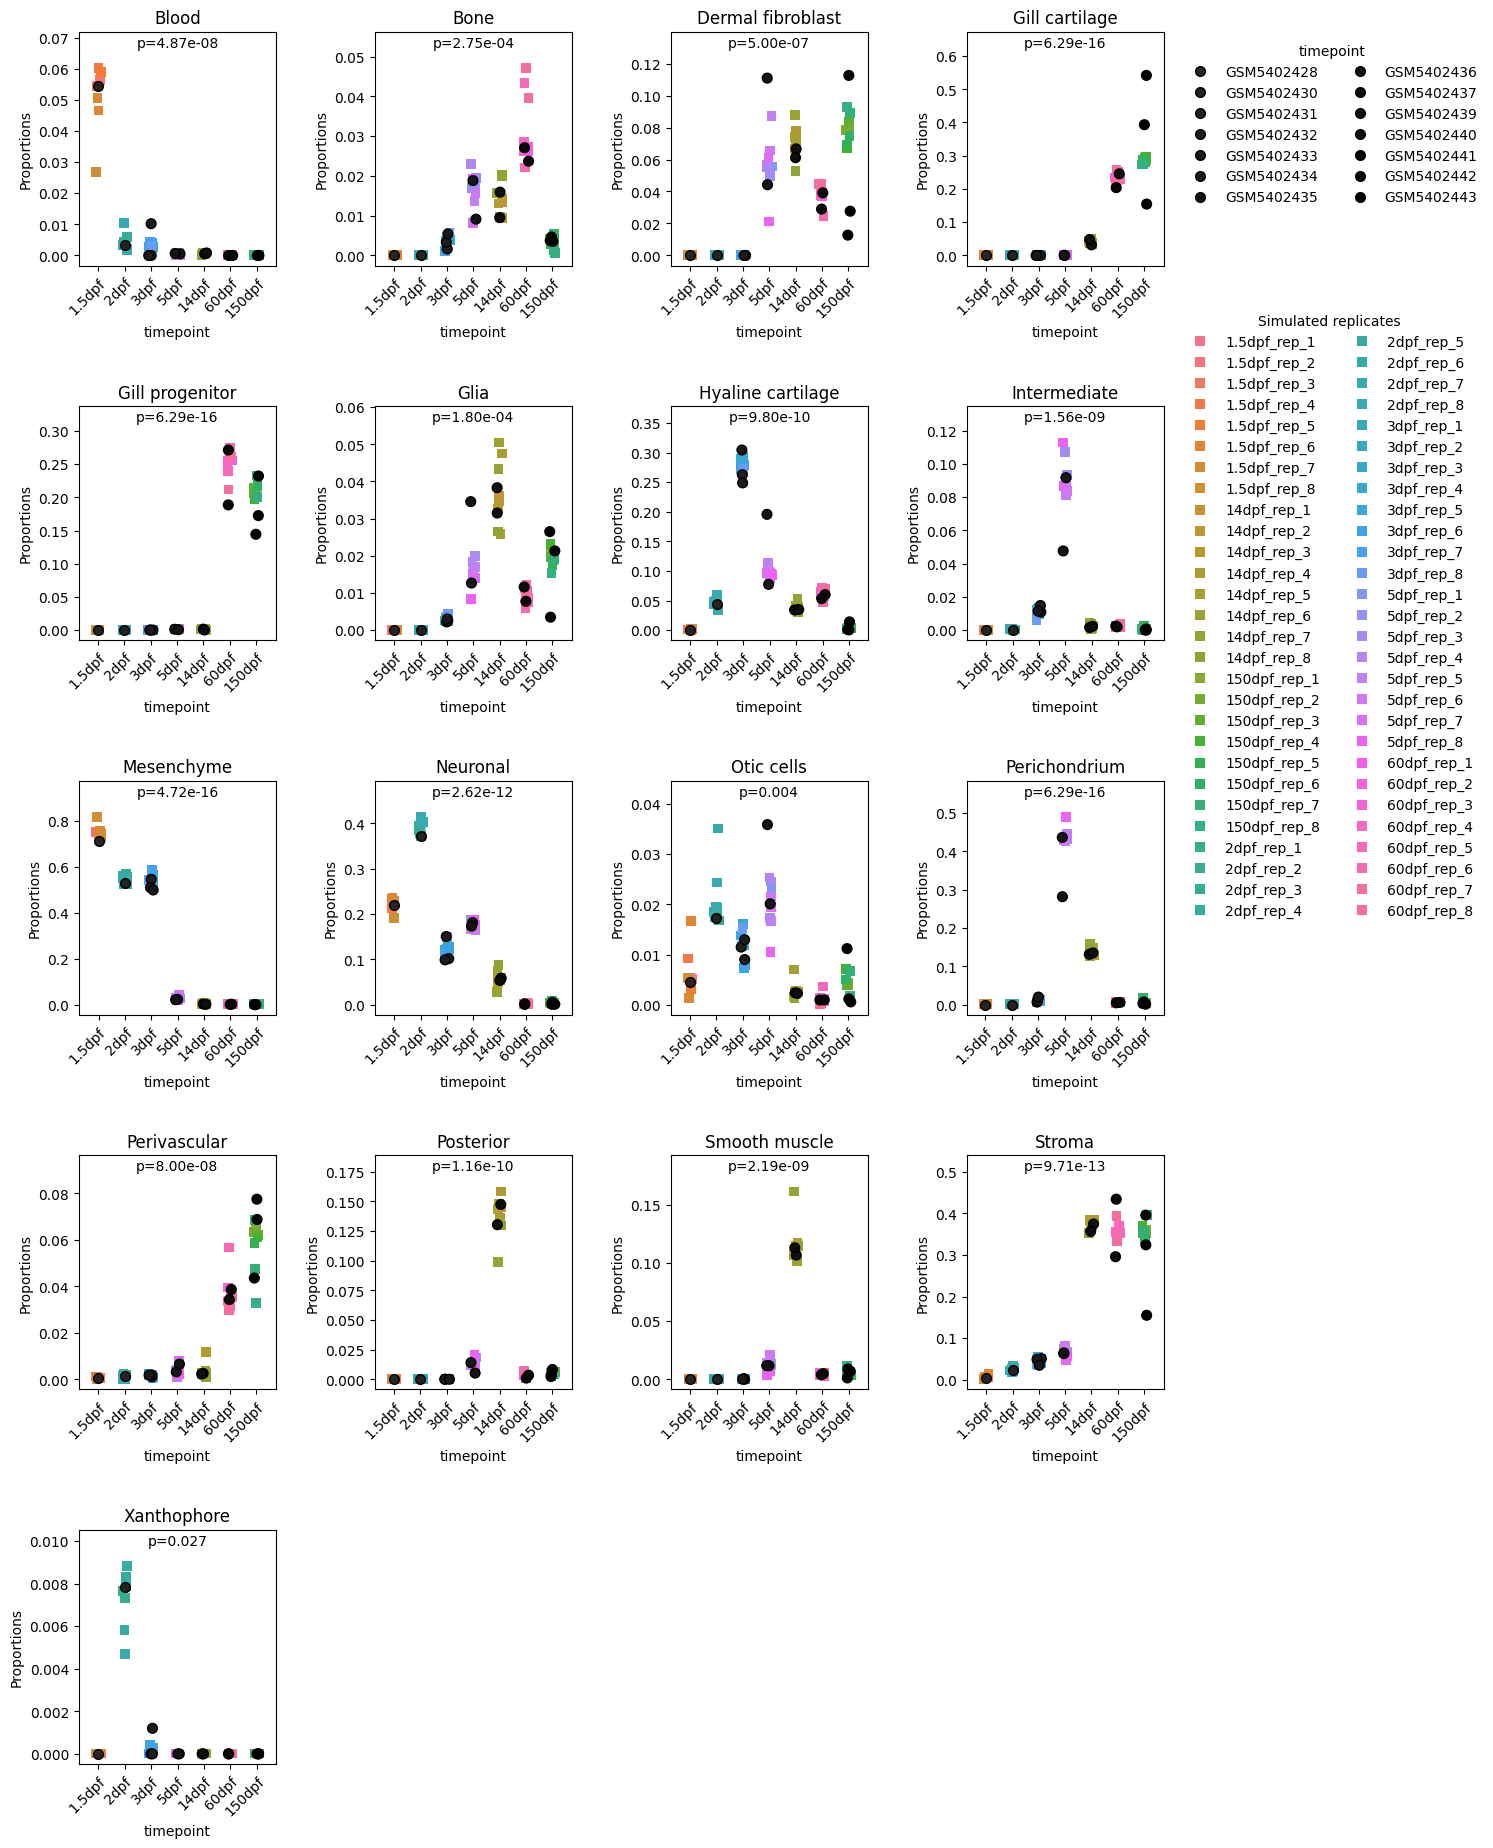

In [10]:
# Plot scanpro results to specific destination folder for automated report generation 
out.plot(kind='stripplot',
         clusters=specific_clusters,
         n_columns=n_cols,
         show=False,
         verbosity=0,
         save=Path(settings.report_dir) / f'02_{plot_suffix}_stripplot.png')
plt.close()

out.plot(kind='stripplot',
         clusters=specific_clusters,
         n_columns=n_cols,
         save=Path(settings.figure_dir) / f'{plot_suffix}_stripplot.pdf')

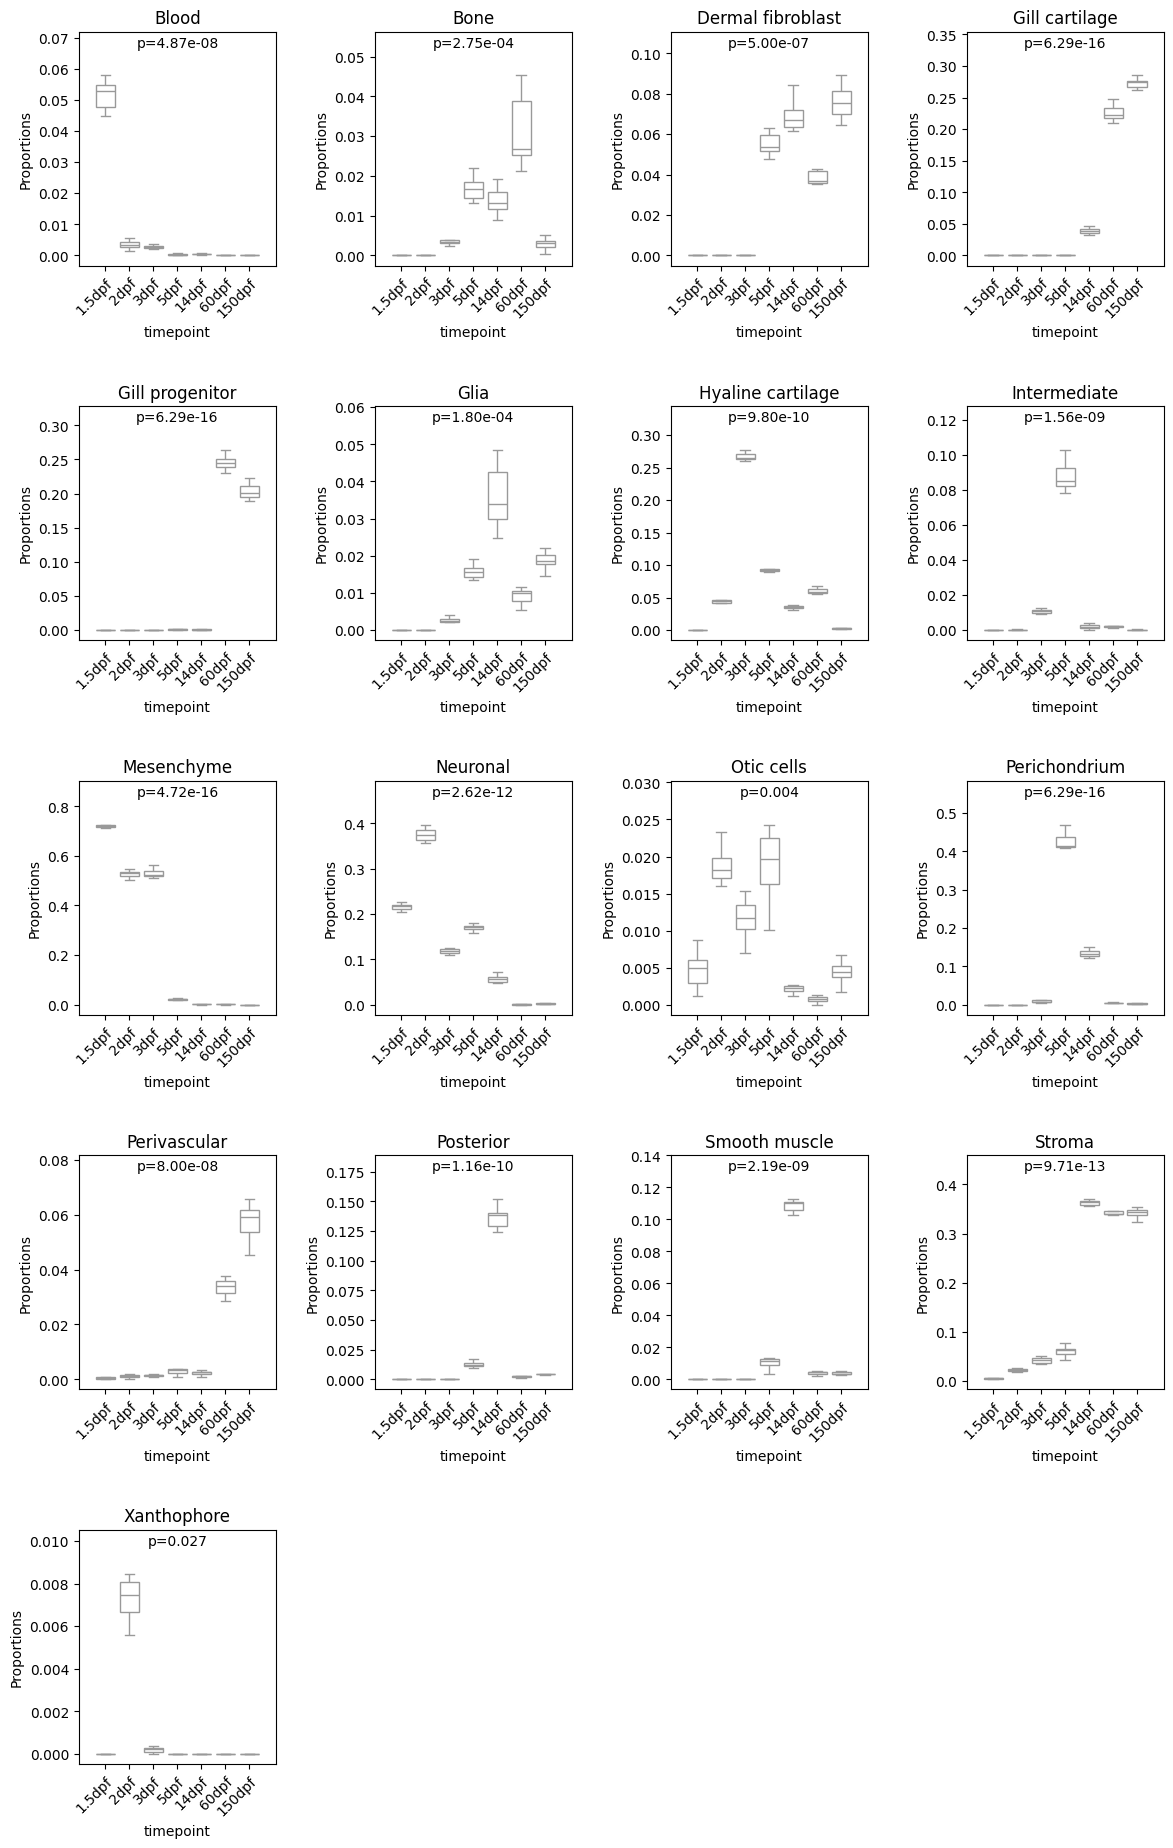

In [11]:
# Plot scanpro results to specific destination folder for automated report generation 
out.plot(kind='boxplot',
         clusters=specific_clusters,
         n_columns=n_cols,
         show=False,
         verbosity=0,
         save=Path(settings.report_dir) / f'03_{plot_suffix}_boxplot.png')
plt.close()

out.plot(kind='boxplot',
         clusters=specific_clusters,
         n_columns=n_cols,
         save=Path(settings.figure_dir) / f'{plot_suffix}_boxplot.pdf')

The above plots show the proportion (amount) of cells of each group (e.g. cell type) allocated to each of the conditions. The p-value on top of each plot describes whether there is a significant change in proportion between any of the conditions. In case there are no replicates Scanpro will create simulated replicates (similar to random subsamples) to improve statistical robustness. The replicates are either shown as separate entities (upper plot) or as a box-distribution (lower plot). E.g. for a dataset where `clustering_col = "celltype"` and `condition_col = "injury"` a plot with low p-value can be interpreted as "Cell Type X shows a high change in the number of cells between injured and healthy" and a high p-value can be interpreted as "Cell Type Y shows a low change in the number of cells between injured and healthy".

In [12]:
# Save results to uns dictionary
scanpro_uns_dict = {"scanpro": {"results": out.results,
                                "significance": significant_change,
                                "proportions": out.props,
                                "counts": out.counts,
                                "transformation": trans,
                                "conditions": out.conditions}}
# Add to adata
adata.uns.update(scanpro_uns_dict)

___

## 7 - Saving adata

In [13]:
utils.io.update_yaml(d={"cluster": clustering_col, "condition": condition_col}, yml="method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, output)

[INFO] The adata object was saved to: ../adatas/anndata_scanpro.h5ad


In [14]:
settings.close_logfile()